In [3]:
import torch

act_scales = torch.load(
    "/content/drive/MyDrive/FYP/quant_stats_gemma/act_scales/gemma-2-2b.pt",
    map_location="cpu"
)

act_shifts = torch.load(
    "/content/drive/MyDrive/FYP/quant_stats_gemma/act_shifts/gemma-2-2b.pt",
    map_location="cpu"
)


In [4]:
import os

# Check for the directory containing act_scales
scales_dir = "/content/drive/MyDrive/FYP/quant_stats_gemma/act_scales"
print(f"Checking directory: {scales_dir}")
if os.path.exists(scales_dir):
    print(f"Contents of {scales_dir}:")
    for item in os.listdir(scales_dir):
        print(f"  - {item}")
else:
    print(f"Directory not found: {scales_dir}")

# Check for the directory containing act_shifts
shifts_dir = "/content/drive/MyDrive/FYP/quant_stats_gemma/act_shifts"
print(f"\nChecking directory: {shifts_dir}")
if os.path.exists(shifts_dir):
    print(f"Contents of {shifts_dir}:")
    for item in os.listdir(shifts_dir):
        print(f"  - {item}")
else:
    print(f"Directory not found: {shifts_dir}")


Checking directory: /content/drive/MyDrive/FYP/quant_stats_gemma/act_scales
Contents of /content/drive/MyDrive/FYP/quant_stats_gemma/act_scales:
  - gemma-2-9b.pt
  - gemma-2-2b.pt

Checking directory: /content/drive/MyDrive/FYP/quant_stats_gemma/act_shifts
Contents of /content/drive/MyDrive/FYP/quant_stats_gemma/act_shifts:
  - gemma-2-9b.pt
  - gemma-2-2b.pt


Please examine the output above to confirm that `gemma-2-2b.pt` is present in the `act_scales` directory and `gemma-2-9b.pt` is present in the `act_shifts` directory. If the files or directories are not found, or if their names are different, please adjust the paths in the `torch.load` cell accordingly.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
layer_name = "model.layers.0.self_attn.v_proj"
scales = act_scales[layer_name]

print(type(scales))
print(scales.shape[0])
print(scales[:10])
print("min :", scales.min().item())
print("max :", scales.max().item())
print("mean:", scales.mean().item())


<class 'torch.Tensor'>
torch.Size([2048])
tensor([0.0000, 4.9453, 2.6367, 3.6504, 3.7168, 1.3848, 4.8828, 6.1367, 3.9805,
        6.3359])
min : 0.0
max : 15.6875
mean: 3.6246557235717773


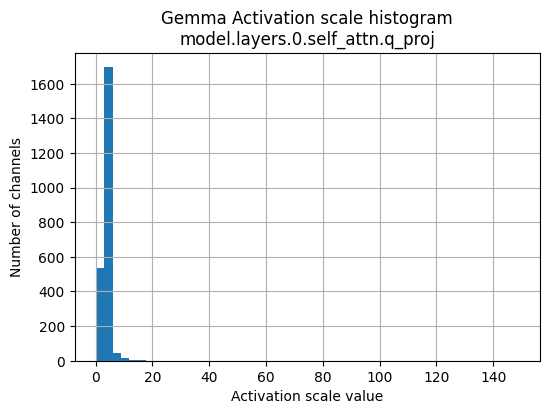

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(scales.numpy(), bins=50)
plt.xlabel("Activation scale value")
plt.ylabel("Number of channels")
plt.title(f"Gemma Activation scale histogram\n{layer_name}")
plt.grid(True)
plt.show()


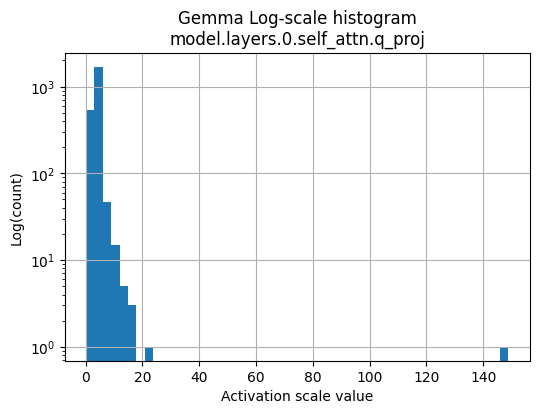

In [ ]:
plt.figure(figsize=(6,4))
plt.hist(scales.numpy(), bins=50, log=True)
plt.xlabel("Activation scale value")
plt.ylabel("Log(count)")
plt.title(f"Gemma Log-scale histogram\n{layer_name}")
plt.grid(True)
plt.show()
